# Stage 2 and Stage 3. Quality Control and Illumination Normalization

Notebook ini menjalankan quality control pada citra ROI fingertip/nail hasil Stage 1, lalu menstabilkan pencahayaan memakai CLAHE pada channel V dan menandai pixel valid sebelum ekstraksi fitur. Kedua fungsi dipakai langsung dari src.common tanpa modifikasi khusus nail, mengikuti pola konjungtiva.

## Environment Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from configs import paths
from src.common import qc, preprocess

output_dir = paths.outputs_dir("nail")
manifest = pd.read_csv(output_dir / "manifest.csv")
manifest_with_roi = manifest[manifest["roi_precropped"]].reset_index(drop=True)
print("total manifest", len(manifest), "dengan roi siap pakai", len(manifest_with_roi))

total manifest 803 dengan roi siap pakai 803


## Quality Control Metrics

Setiap ROI dinilai berdasarkan ketajaman, kecerahan, fraksi glare, dan luas region of interest, memakai ambang default yang sama dipakai konjungtiva dan palm. Baris yang tidak lolos tetap dicatat di qc_report untuk transparansi, penentuan buang atau tidaknya baris dilakukan di stage berikutnya, bukan di notebook ini.

In [2]:
qc_report = qc.run_quality_check(manifest_with_roi)
print("overall pass rate", round(100 * qc_report["passed"].mean(), 1), "percent")
print()
reasons = qc_report.loc[~qc_report["passed"], "reasons"].str.split(",").explode()
print("failure reasons:")
print(reasons[reasons != ""].value_counts().to_string())

overall pass rate 99.6 percent

failure reasons:
reasons
glare    3


## Metric Distributions

Distribusi ketiga metrik utama membantu memeriksa apakah ambang default konjungtiva juga wajar dipakai pada ROI fingertip/nail yang jauh lebih kecil ukurannya.

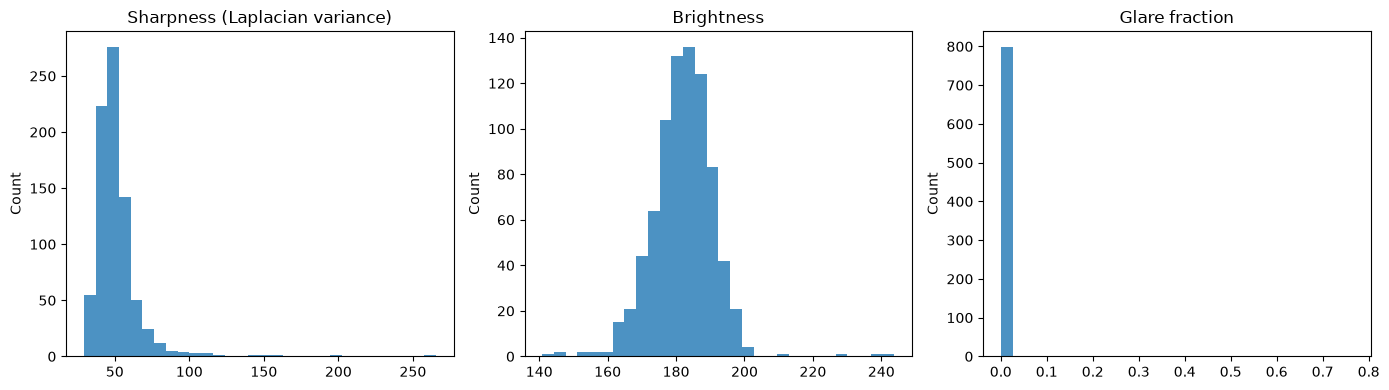

In [3]:
columns = ["laplacian_variance", "brightness", "glare_fraction"]
titles = ["Sharpness (Laplacian variance)", "Brightness", "Glare fraction"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, column, title in zip(axes, columns, titles):
    ax.hist(qc_report[column], bins=30, alpha=0.8)
    ax.set_title(title)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## Illumination Normalization

CLAHE pada channel V meningkatkan kontras lokal dan meredam pencahayaan tidak merata tanpa mengubah informasi warna. Satu sampel lolos QC dan satu sampel gagal QC (bila ada) ditampilkan untuk pemeriksaan visual.

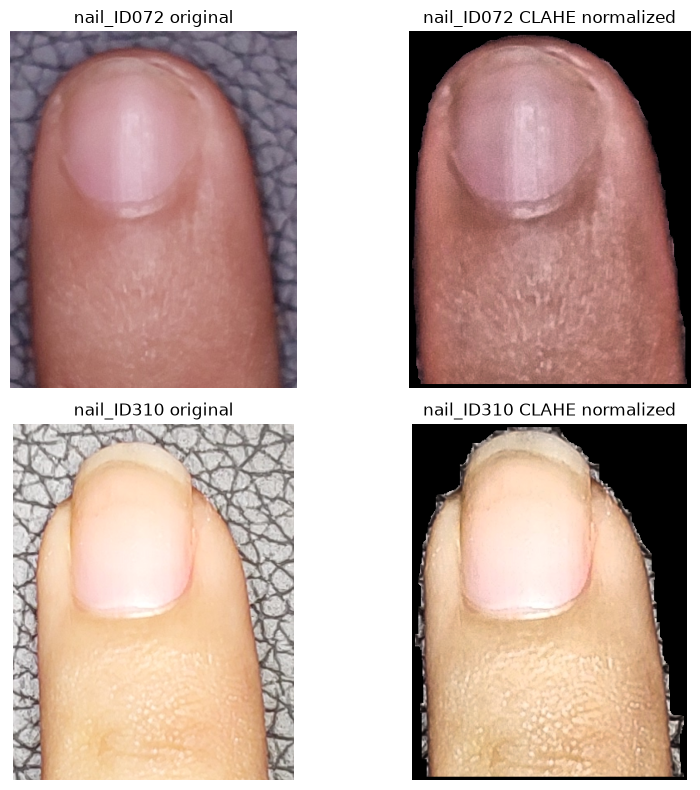

In [4]:
passed_uid = qc_report[qc_report["passed"]].sample(1, random_state=7).iloc[0]["uid"]
samples = [passed_uid]
failed = qc_report[~qc_report["passed"]]
if len(failed) > 0:
    samples.append(failed.sample(1, random_state=7).iloc[0]["uid"])

fig, axes = plt.subplots(len(samples), 2, figsize=(9, 4 * len(samples)))
axes = np.atleast_2d(axes)
for ax_row, uid in zip(axes, samples):
    roi_path = manifest_with_roi.loc[manifest_with_roi["uid"] == uid, "roi_path"].iloc[0]
    original, _ = qc.load_roi(roi_path)
    result = preprocess.normalize_roi(roi_path)
    ax_row[0].imshow(original)
    ax_row[0].set_title(f"{uid} original")
    ax_row[1].imshow(result["rgb"])
    ax_row[1].set_title(f"{uid} CLAHE normalized")
    for ax in ax_row:
        ax.axis("off")
plt.tight_layout()
plt.show()

## Valid Pixel Filtering

Setelah normalisasi, pixel yang terlalu gelap atau terlalu terang dibuang agar ekstraksi fitur hanya memakai area kuku dan kulit ujung jari yang representatif.

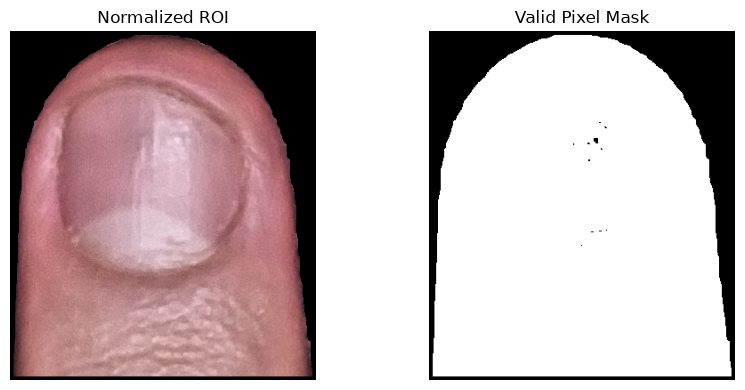

In [5]:
row = manifest_with_roi.iloc[0]
result = preprocess.normalize_roi(row["roi_path"])
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(result["rgb"])
axes[0].set_title("Normalized ROI")
axes[1].imshow(result["valid_mask"], cmap="gray")
axes[1].set_title("Valid Pixel Mask")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Save QC Report

In [6]:
output_path = output_dir / "qc_report.csv"
qc_report.to_csv(output_path, index=False)
print("qc report saved to", output_path)

qc report saved to /home/praktikan/projects/Azril/hemavision/outputs/nail/qc_report.csv
